In [1]:
#Импортируем настройки
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("done")

done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/BMW sales data (2010-2024).csv'

In [4]:
try:
    df = pd.read_csv(file_path)
    print("датасет загружен")
    print(f"{df.shape[0]} строк, {df.shape[1]} столбцов")
except FileNotFoundError:
    print("Файл не найден. Проверьте путь к файлу!")
    print("Текущая директория:")
    !ls /content/drive/MyDrive/


датасет загружен
2000 строк, 11 столбцов


Шаг 1. Загрузили все необходимые настройки, дали доступ к гугл диску, загрузили файл и проверили, что он отображается корректно

Первичный анализ данных (EDA). Меняем название файлика на bmw.df, используем кодировку ascii (позволительно, у нас ascii символы), выводим ключевую информацию через info().
- **duplicated().sum()** считает количество полных дубликатов строк (все колонки совпадают)
- **isna().sum()** считает пропуски в каждой колонке
- **sort_values(ascending=False)** сортирует колонки по убыванию количества пропусков сверху вниз

Бизнесу не нужен точный объем продаж (Sales_Volume), бизнесу нужно бинарное решение брать или не брать? Мы хотим предсказать успех продаж, поэтому выбираем целевую колонку Sales_Classification, которая отражает успешность продаж автомобиля:
  - High = быстрая продажа, высокий спрос
  - Low = низкий спрос, залеживающийся товар



---



In [5]:
bmw_df = pd.read_csv(file_path, encoding="ascii")

print(bmw_df.head())
print("\
--- info() ---")
print(bmw_df.info())

dup_count = int(bmw_df.duplicated().sum())
na_counts = bmw_df.isna().sum().sort_values(ascending=False)
print("\
Дубликаты:")
print(dup_count)
print("\
Пропущенные значения:")
print(na_counts.head(15))

num_cols = bmw_df.select_dtypes(include=["number"]).columns.tolist()
print("\
--- describe() numeric ---")
print(bmw_df[num_cols].describe().T)

#Целевое распределение
if "Sales_Classification" not in bmw_df.columns:
    raise ValueError("Target column Sales_Classification not found")

class_pct = (bmw_df["Sales_Classification"].value_counts(normalize=True) * 100).round(2)
print("\
--- Class distribution (%) ---")
print(class_pct)

      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  
--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        

Вывели кол-во дубликатов и топ-15 колонок с наибольшим числом пропусков (пропусков не оказалось). Далее игнорируем категориальные и текстовые колонки, создаем список только числовых колонок.
- через describe() вычисляем базовые статистики
- через .t() транспонируем табличку чтобы увидеть выбросы, масштаб признаков и пропуски

Мы выбрали целевую колонку Sales_Classification, проверяем ее наличие и считаем:
- частоту каждого класса в процентах
- вводим распределение классов


Итого:
- 1\ узнаем типы колонок
- 2\ есть ли пропуски
- 3\ есть ли дубликаты
- 4\ нужно ли масштабирование
- 5\ дисбаланс классов

Вывод по EDA:


---


Типы колонок
- **1\ object (категориальные)**. Сюда входят: 	Model, Region, Color, Fuel_Type, Transmission, Sales_Classification. Количество: 6
- **2\ int64 (числовые целые)**. Сюда входят:	Year, Mileage_KM, Price_USD, Sales_Volume. Количество: 4
- **3\ float64 (числовые вещественные)**. Сюда входят:	Engine_Size_L	. Количество: 1


---

Качество данных: 0 дубликатов и 0 пропусков. Датасет не требует очистки от пропусков или дубликатов.


---

Целевое распределение:
- Low:  68.35% (1,367 записей)
- High: 31.65% (633 записи)

* Дисбаланс примерно 2:1 в пользу класса Low


---


Выбор метрики:
- Почему не accurancy: при дисбалансе 68/32 модель, предсказывающая все как Low, получит 68% accuracy --> ложное впечатление хорошего качества
- Почему F1 score: позволяет найти компромисс между нахождением High-продаж (Recall) и минимизацией ошибок (Precision), дает честную оценку на несбалансированных данных.


Визуализируем:

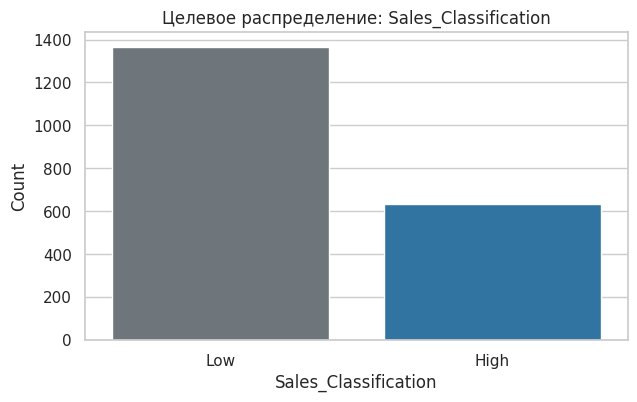

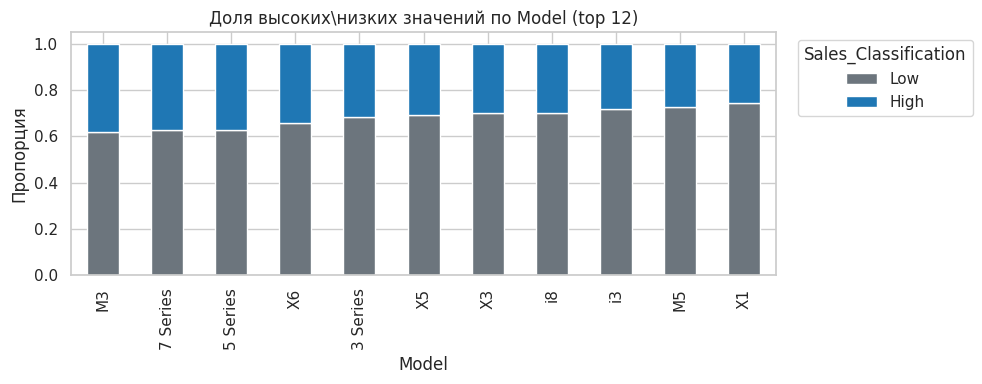

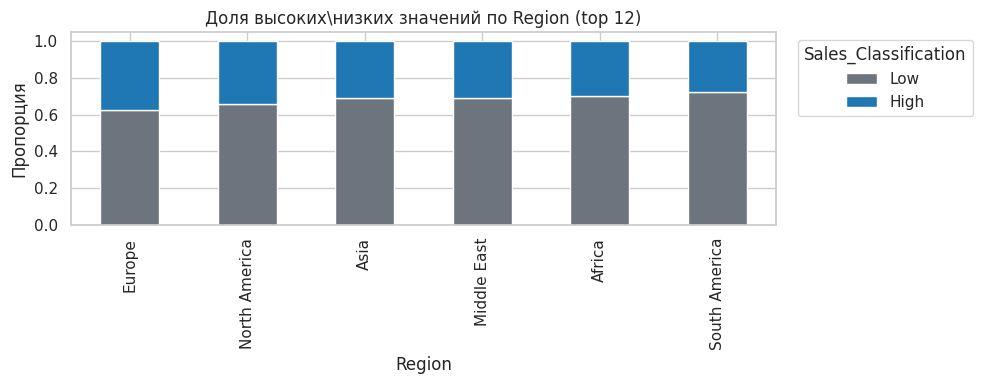

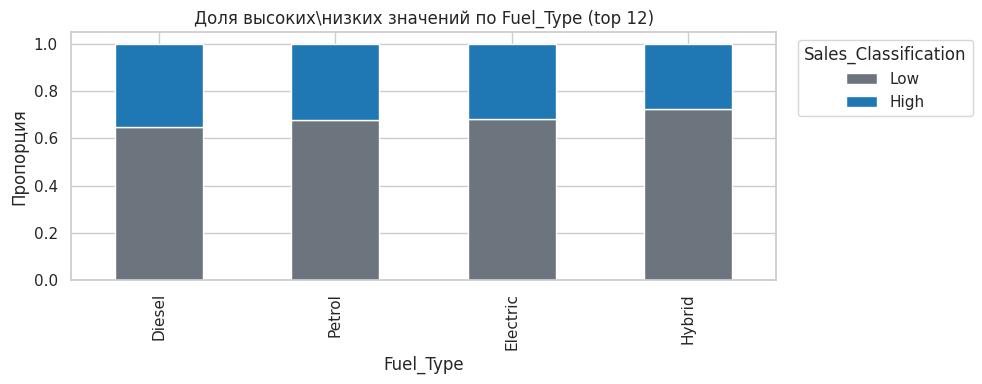

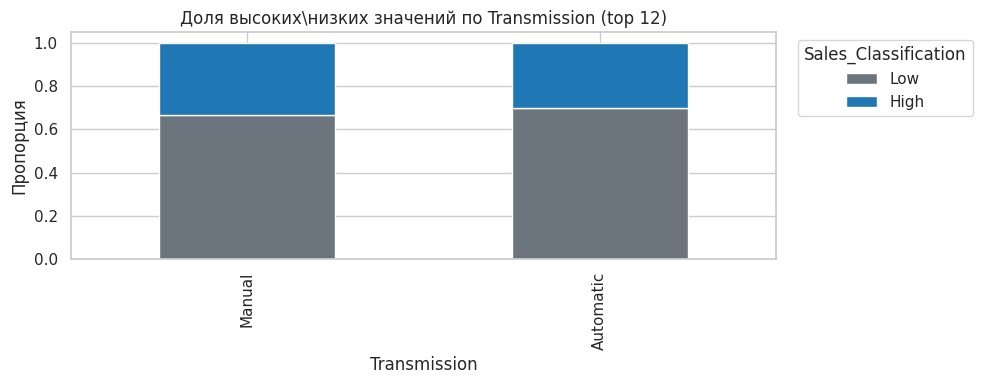

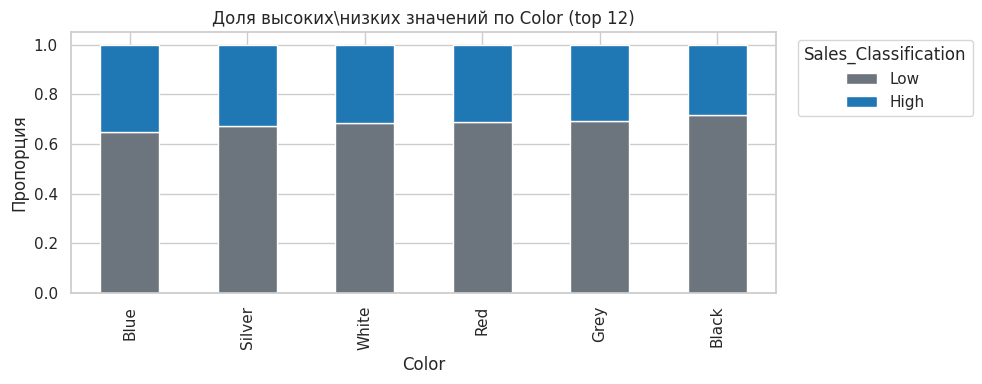

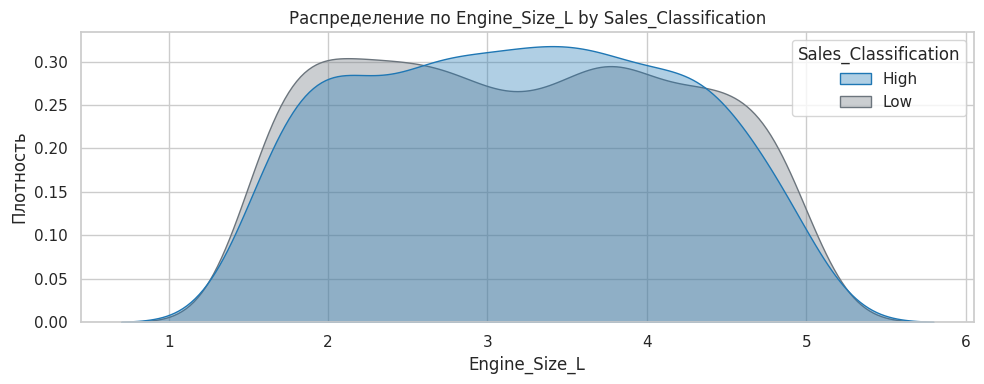

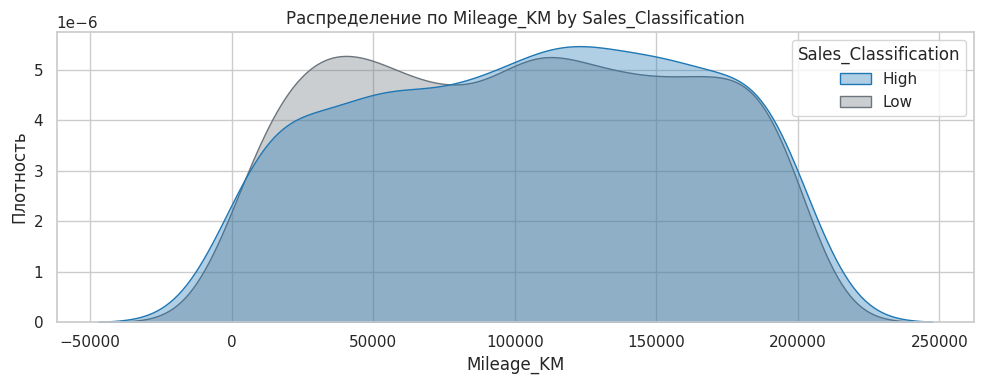

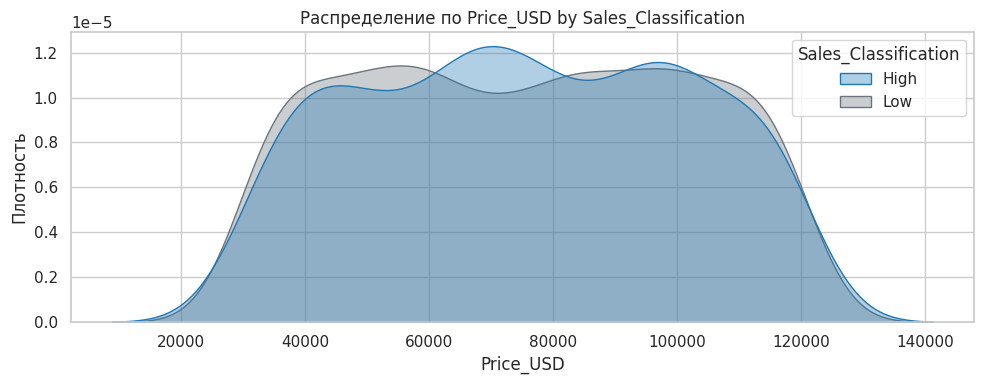

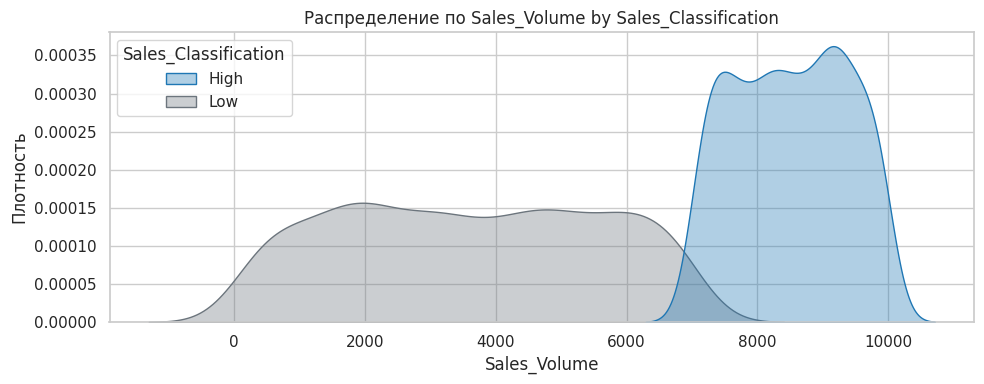

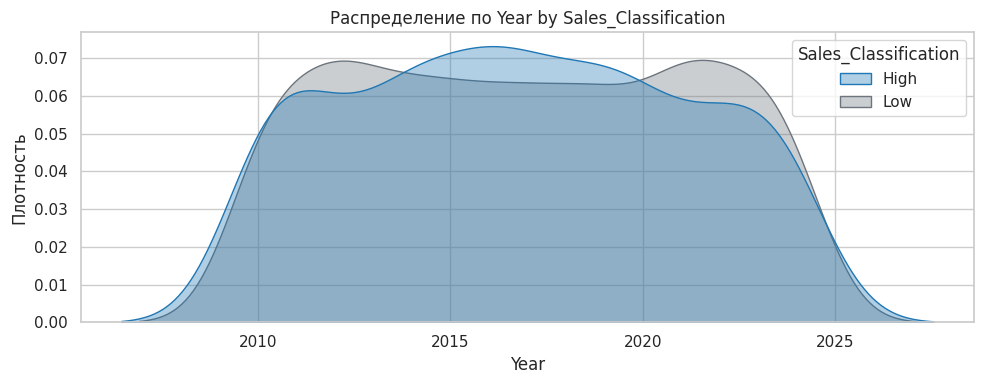

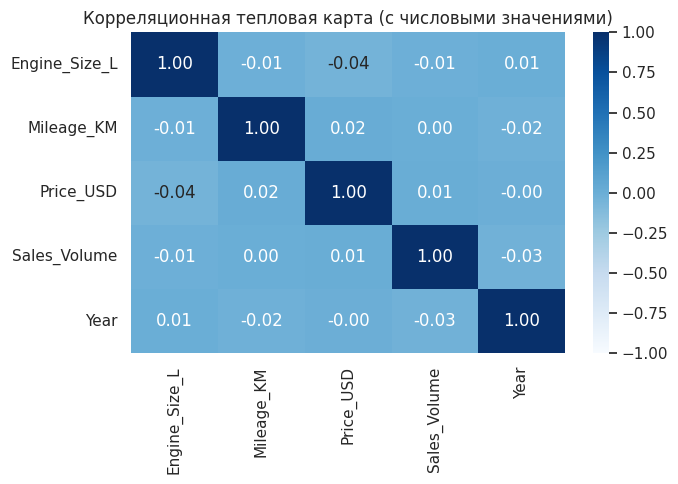

In [6]:
#Визуализация EDA
#Сосредоточимся на целевых характеристиках, а не на ключевых особенностях распределения

#Каунтплот целевого значения
plt.figure(figsize=(7,4))
sns.countplot(data=bmw_df, x="Sales_Classification", order=["Low","High"], palette=["#6c757d", "#1f77b4"])
plt.title("Целевое распределение: Sales_Classification")
plt.xlabel("Sales_Classification")
plt.ylabel("Count")
plt.show()

#Классификация продаж против категориальныз признаков
cat_cols = ["Model","Region","Fuel_Type","Transmission","Color"]

for cat_col in cat_cols:
    ct = pd.crosstab(bmw_df[cat_col], bmw_df["Sales_Classification"], normalize="index")
    ct = ct[["Low","High"]] if set(["Low","High"]).issubset(ct.columns) else ct
    ct = ct.sort_values(by="High", ascending=False) if "High" in ct.columns else ct

    top_n = 12
    ct_plot = ct.head(top_n)

    ax = ct_plot.plot(kind="bar", stacked=True, figsize=(10,4), color=["#6c757d", "#1f77b4"])
    plt.title("Доля высоких\низких значений по " + cat_col + " (top " + str(top_n) + ")")
    plt.xlabel(cat_col)
    plt.ylabel("Пропорция")
    plt.legend(title="Sales_Classification", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

#Числовое распределение по классам
num_cols = ["Engine_Size_L","Mileage_KM","Price_USD","Sales_Volume","Year"]

for col_name in num_cols:
    plt.figure(figsize=(10,4))
    sns.kdeplot(data=bmw_df, x=col_name, hue="Sales_Classification", common_norm=False, fill=True, alpha=0.35,
               palette={"Low":"#6c757d","High":"#1f77b4"})
    plt.title("Распределение по " + col_name + " by Sales_Classification")
    plt.xlabel(col_name)
    plt.ylabel("Плотность")
    plt.tight_layout()
    plt.show()

#Тепловая карта корреляций
plt.figure(figsize=(7,5))
corr_mat = bmw_df[num_cols].corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Корреляционная тепловая карта (с числовыми значениями)")
plt.tight_layout()
plt.show()

Анализ визуализаций EDA.


---

- 1\Каунтплот целевой переменной - дибаланс супер очевидный, что типично для розничных продаж (большинство товаров продается плохо, меньшинство продается отлично)
- 2\ Дилеры BMW сталкиваются с тем, что только каждый третий автомобиль на вторичном рынке является быстрооборачиваемым



---

Анализ категориальных признаков (наблюдения из то-12)
- 1\ Модели М3, 7 series, 5 series имеют высокую долю high (отлично-продаваемые) под общую массу людей с доступной ценой и доступным сервисом (адекватны в обслуживании)
- 2\ М5, i3, x1 очень высокая доля low (плохо продаются). i3-электричка, не настолько популярны чем ДВС (меньше подходит под желания покупателей). M5 достаточно дорогая, она не про удобство, а про скорость (низкая, не подходит под многие дороги), x1 - маленький внедорожник (ни туда, ни сюда), цена завышена, как у нормального седана.
- 3\ В Европе машины BMW продаются лучше (что логично, ведь его семейство производится в Германии, следовательно более доступен)
В северной Америке продаются хуже - у американцев свой хороший рынок машин, плюс далеко - издержки за логистику (у них нет заводов, в Китае например есть)
- 4\ Дизельные модели BMW больше пользуются спросом, чем Гибриды, потому что дизель надежнее и движки поинтереснее +  рынок еще не полностью перешел на электротягу в 2010-2020 годах
- 5\ В синим цвете продается лучше, чем в остальных, так как это сразу ассоциация с БМВ. Красивый глубокий цвет, интересный + кузовные детали в синем цвете легче найти, чем в остальных цветах + предпочтения людей


---

Числовые распределения по классам
- Обязательно удалить Sales_Volume (Объем продаж) - здесь явное разделение: low имеет низкие объемы, high — высокие


---

Тепловая карта корреляций с почти нулевыми значениями - очень плохо, такое практически невозможно и может указывать на ошибку. Попробуем сделать еще раз на исходных данных

                   Year  Engine_Size_L  Mileage_KM  Price_USD  Sales_Volume
Year           1.000000       0.006394   -0.015805  -0.001048     -0.025116
Engine_Size_L  0.006394       1.000000   -0.010327  -0.039453     -0.013088
Mileage_KM    -0.015805      -0.010327    1.000000   0.021846      0.002933
Price_USD     -0.001048      -0.039453    0.021846   1.000000      0.014537
Sales_Volume  -0.025116      -0.013088    0.002933   0.014537      1.000000


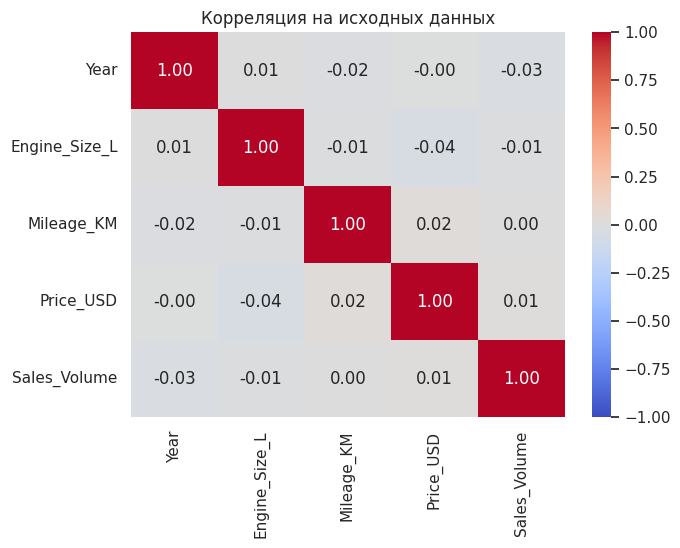

In [7]:
#Загрузим данные снова
bmw_raw = pd.read_csv(file_path, encoding="ascii")

#Числовые колонки в исходных данных
num_cols_raw = ["Year", "Engine_Size_L", "Mileage_KM", "Price_USD", "Sales_Volume"]

# орреляция на сырых данных
corr_raw = bmw_raw[num_cols_raw].corr()
print(corr_raw)

#Тепловая карта
plt.figure(figsize=(7,5))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляция на исходных данных")
plt.show()

Вывод: проблема в самих данных (возможно, они синтетические или сильно искажены).

Создаем пайплайн предобработки, который позже будет применен к train и test данным

In [8]:
#Разделение на обучающую и тестовую выборку + предварительная обработка
# Работаем с нашей целевой переменной, преобразуем High в 1, Low в 0

target_col = "Sales_Classification"

X = bmw_df.drop(columns=[target_col]) #все признаки, кроме целевой
y = (bmw_df[target_col].astype(str).str.strip() == "High").astype(int)

#Разделяем признаки на числовые и категориальные
numeric_features = ["Year", "Engine_Size_L", "Mileage_KM", "Price_USD", "Sales_Volume"]
categorical_features = [c for c in X.columns if c not in numeric_features]

#Стратифицированное разделение (сохраняем пропорцию классов 68/32)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Pipeline для числовых признаков- заполняем пропуски медианой и масштабируем
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline для категориальных - заполняем пропуски самой частой категорией и  One-Hot кодирование
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Объединяем оба pipeline в один ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Train size:")
print(X_train.shape[0])
print("Test size:")
print(X_test.shape[0])
print("Positive rate in train:")
print(float(y_train.mean()))
print("Positive rate in test:")
print(float(y_test.mean()))

Train size:
1600
Test size:
400
Positive rate in train:
0.31625
Positive rate in test:
0.3175


 Разделение выполнено правильно, тестовая выборка достаточно большая для надежной оценки качества (400 объектов - статистически значимо). В обучающей выборке 31.6% автомобилей относятся к классу High, 68.4% - к классу Low. Стратратификация успешно применена, тестовая выборка репрезентативна. Далее будем определять лучшую модель с метриками при пороге 0.5 по F1

In [9]:
#Определяем лучшую модель джля обучения при пороговом значении 0.5
from collections import OrderedDict

models = OrderedDict()

# Логичестическая регрессия с балансировкой весов классов
models["LogReg"] = LogisticRegression(max_iter=3000, class_weight="balanced", n_jobs=None)

#Рандомфорест
models["RandomForest"] = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

#XGBoost (с корректировкой scale_pos_weight для дисбаланса)
xgb_available = True
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=700,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
except Exception as exc:
    xgb_available = False
    print("XGBoost not available, will skip. Error:")
    print(str(exc))

#Обучаем каждую модель через Pipeline (предобработка + модель)
pipelines = {}
for model_name in models:
    pipelines[model_name] = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", models[model_name])
    ])

results_rows = []
proba_store = {}

for model_name in pipelines:
    pipe_obj = pipelines[model_name]
    pipe_obj.fit(X_train, y_train)

    #Считаем метрики и предсказание
    y_proba = pipe_obj.predict_proba(X_test)[:, 1]
    y_pred_05 = (y_proba >= 0.5).astype(int)

    f1_high = f1_score(y_test, y_pred_05, pos_label=1)
    prec_high = precision_score(y_test, y_pred_05, pos_label=1, zero_division=0)
    rec_high = recall_score(y_test, y_pred_05, pos_label=1, zero_division=0)
    auc_val = roc_auc_score(y_test, y_proba)

    results_rows.append({
        "model": model_name,
        "f1_high@0.5": f1_high,
        "precision_high@0.5": prec_high,
        "recall_high@0.5": rec_high,
        "roc_auc": auc_val
    })

    proba_store[model_name] = y_proba

results_df = pd.DataFrame(results_rows).sort_values(by="f1_high@0.5", ascending=False).reset_index(drop=True)
print(results_df)

best_model_name = str(results_df.loc[0, "model"])
print("\
Best model by F1@0.5:")
print(best_model_name)

          model  f1_high@0.5  precision_high@0.5  recall_high@0.5  roc_auc
0  RandomForest     1.000000            1.000000         1.000000  1.00000
1       XGBoost     1.000000            1.000000         1.000000  1.00000
2        LogReg     0.972973            0.954545         0.992126  0.99974
Best model by F1@0.5:
RandomForest


Лучшей моделью оказался рандомфорест, теперь нужно понять, можно ли идеально классифицировать, используя только Sales_Volume. Если да - утечка данных

Sales_Classification   High    Low
Sales_Volume_bin                  
(100.999, 1218.6]     0.000  1.000
(1218.6, 2139.6]      0.000  1.000
(2139.6, 3144.9]      0.000  1.000
(3144.9, 4230.8]      0.000  1.000
(4230.8, 5170.5]      0.000  1.000
(5170.5, 6188.8]      0.000  1.000
(6188.8, 7168.3]      0.165  0.835
(7168.3, 8138.2]      1.000  0.000
(8138.2, 9098.2]      1.000  0.000
(9098.2, 9996.0]      1.000  0.000
Best single-threshold F1 using Sales_Volume only:
1.0
Threshold:
7001.5
Confusion matrix (Sales_Volume threshold):
[[1367    0]
 [   0  633]]


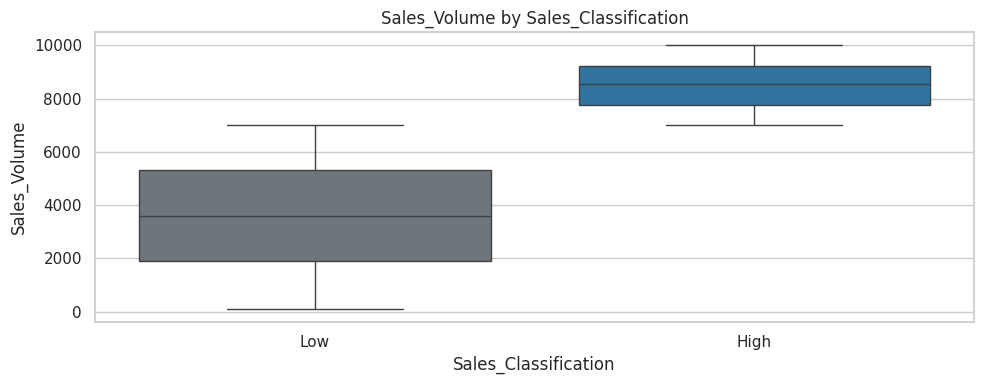

In [10]:
# Кросс-таблица Sales_Classification и квартилей Sales_Volume
bmw_df_tmp = bmw_df.copy()
bmw_df_tmp["Sales_Volume_bin"] = pd.qcut(bmw_df_tmp["Sales_Volume"], q=10, duplicates="drop")
ct = pd.crosstab(bmw_df_tmp["Sales_Volume_bin"], bmw_df_tmp["Sales_Classification"], normalize="index")
print(ct)

#может ли один порог Sales_Volume идеально классифицировать
sv = bmw_df["Sales_Volume"].to_numpy()
y_true = (bmw_df["Sales_Classification"] == "High").astype(int).to_numpy()

#сканируем уникальные значения
unique_vals = np.unique(sv)

cand_thr = (unique_vals[:-1] + unique_vals[1:]) / 2.0

best_f1 = -1
best_thr = None
for thr in cand_thr:
    y_hat = (sv >= thr).astype(int)
    f1_val = f1_score(y_true, y_hat)
    if f1_val > best_f1:
        best_f1 = f1_val
        best_thr = float(thr)

print("\
Best single-threshold F1 using Sales_Volume only:")
print(best_f1)
print("Threshold:")
print(best_thr)

#Матрица ошибок
if best_thr is not None:
    y_hat_best = (sv >= best_thr).astype(int)
    print("\
Confusion matrix (Sales_Volume threshold):")
    print(confusion_matrix(y_true, y_hat_best))

# Плот Sales_Volume по классу
plt.figure(figsize=(10,4))
sns.boxplot(data=bmw_df, x="Sales_Classification", y="Sales_Volume", order=["Low","High"],
            palette=["#6c757d", "#1f77b4"])
plt.title("Sales_Volume by Sales_Classification")
plt.xlabel("Sales_Classification")
plt.ylabel("Sales_Volume")
plt.tight_layout()
plt.show()

Столкнулись с проблемой :). F1 = 1.0 и означает идеальную классификацию только по признаку объема продаж + идеальное распределение (0 ошибок, 100% точность) + Boxplot показывает, что ящики классов Low и High не перекрываются - признак идеального разделения. В итоге: Sales_Volume был использован для создания Sales_Classification. Теперь нам нужно:
* 1\ переобучить модель без sales_Volume
* 2\ определить признаки, которые реально влияют на успешность продаж
* 3\ добавите feature importance и потимизацию порога
- Иначе наша модель будет бестолковой и бесполезной

Повторное обучение без утечки данных - удаляем Sales_Volume, который давал идеальное разделение и обучаем модели на реальных признаках.

In [11]:
#Удаляем Sales_Volume
numeric_features_correct = ["Year", "Engine_Size_L", "Mileage_KM", "Price_USD"]

# Категориальные признаки остаются те же
categorical_features = ["Model", "Region", "Color", "Fuel_Type", "Transmission"]

# Подготовка данных (заново, без Sales_Volume)
X_correct = bmw_df.drop(columns=["Sales_Classification", "Sales_Volume"])
y_correct = (bmw_df["Sales_Classification"].astype(str).str.strip() == "High").astype(int)

print(f"{X_correct.shape[0]} строк, {X_correct.shape[1]} признаков")
print(f"Класс High: {y_correct.sum()} ({y_correct.mean()*100:.1f}%)")
print(f"Класс Low: {len(y_correct)-y_correct.sum()} ({(1-y_correct.mean())*100:.1f}%)")

# Стратифицированное разделение
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_correct, y_correct, test_size=0.2, random_state=42, stratify=y_correct
)

print(f"Обучающая выборка: {X_train_c.shape[0]} строк")
print(f"High: {y_train_c.sum()} ({y_train_c.mean()*100:.1f}%)")
print(f"Тестовая выборка: {X_test_c.shape[0]} строк")
print(f"high: {y_test_c.sum()} ({y_test_c.mean()*100:.1f}%)")

# Pipeline предобработки
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_correct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_correct),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Модели
models_correct = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, random_state=42, class_weight="balanced", n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=5,
                             random_state=42, n_jobs=-1, eval_metric="logloss", use_label_encoder=False)
}

# Обучение и оценка
pipelines_correct = {}
results_correct = []

for name, model in models_correct.items():
    print(f"\n--- {name} ---")

    pipeline = Pipeline([
        ("preprocess", preprocess_correct),
        ("classifier", model)
    ])

    pipeline.fit(X_train_c, y_train_c)
    pipelines_correct[name] = pipeline

    y_pred = pipeline.predict(X_test_c)
    y_proba = pipeline.predict_proba(X_test_c)[:, 1]

    f1 = f1_score(y_test_c, y_pred, pos_label=1)
    prec = precision_score(y_test_c, y_pred, pos_label=1)
    rec = recall_score(y_test_c, y_pred, pos_label=1)
    auc = roc_auc_score(y_test_c, y_proba)

    results_correct.append({
        "model": name,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "ROC-AUC": auc
    })

    print(f"F1-Score (High): {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"ROC-AUC: {auc:.4f}")

# Сравнение моделей
results_df_correct = pd.DataFrame(results_correct).sort_values("F1-Score", ascending=False)
print(results_df_correct.to_string(index=False))

best_model_name = results_df_correct.iloc[0]["model"]
best_f1 = results_df_correct.iloc[0]["F1-Score"]

print(f"лучшая модель: {best_model_name} (F1-Score = {best_f1:.4f})")

2000 строк, 9 признаков
Класс High: 633 (31.6%)
Класс Low: 1367 (68.3%)
Обучающая выборка: 1600 строк
High: 506 (31.6%)
Тестовая выборка: 400 строк
high: 127 (31.8%)

--- Logistic Regression ---
F1-Score (High): 0.4013
Precision: 0.3333
Recall: 0.5039
ROC-AUC: 0.5449

--- Random Forest ---
F1-Score (High): 0.0000
Precision: 0.0000
Recall: 0.0000
ROC-AUC: 0.5337

--- XGBoost ---
F1-Score (High): 0.1675
Precision: 0.2500
Recall: 0.1260
ROC-AUC: 0.5123
              model  F1-Score  Precision   Recall  ROC-AUC
Logistic Regression  0.401254   0.333333 0.503937 0.544922
            XGBoost  0.167539   0.250000 0.125984 0.512273
      Random Forest  0.000000   0.000000 0.000000 0.533703
лучшая модель: Logistic Regression (F1-Score = 0.4013)


Определяем, какие характеристики автомобиля сильнее всего влияют
на предсказание успешных продаж (класс High).

In [14]:
best_pipeline = pipelines_correct[best_model_name]
# Для Logistic Regression смотрим коэффициенты
if best_model_name == "Logistic Regression":
    preprocessor = best_pipeline.named_steps['preprocess']
    model = best_pipeline.named_steps['classifier']

    # Получаем имена признаков
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    all_feature_names = np.concatenate([numeric_features_correct, cat_feature_names])

    coefficients = model.coef_[0]
    abs_coef = np.abs(coefficients)
    indices = np.argsort(abs_coef)[::-1][:10]

    print("Топ признаков по модулю коэффициента")
    for i, idx in enumerate(indices):
        print(f"  {i+1}. {all_feature_names[idx]}: {coefficients[idx]:.4f}")

Топ признаков по модулю коэффициента
  1. Model_M3: 0.3979
  2. Model_X1: -0.3065
  3. Region_Europe: 0.2496
  4. Model_5 Series: 0.2454
  5. Region_South America: -0.2229
  6. Model_M5: -0.2080
  7. Color_Black: -0.1869
  8. Color_Blue: 0.1821
  9. Fuel_Type_Hybrid: -0.1779
  10. Fuel_Type_Diesel: 0.1556


Оптимизация порога классификации - вместо фиксированного порога 0.5 находим оптимальный порог, максимизирующий F1-Score для класса High.

лучшая модель: Logistic Regression
Порог 0.5:
F1-Score: 0.4013
Оптимальный порог: 0.3811
F1-Score при оптимальном пороге: 0.4960
Улучшение: +0.0947 (+23.6%)
Метрики при оптимальнром пороге (0.381):
              precision    recall  f1-score   support

         Low       0.89      0.09      0.16       273
        High       0.33      0.98      0.50       127

    accuracy                           0.37       400
   macro avg       0.61      0.53      0.33       400
weighted avg       0.71      0.37      0.27       400



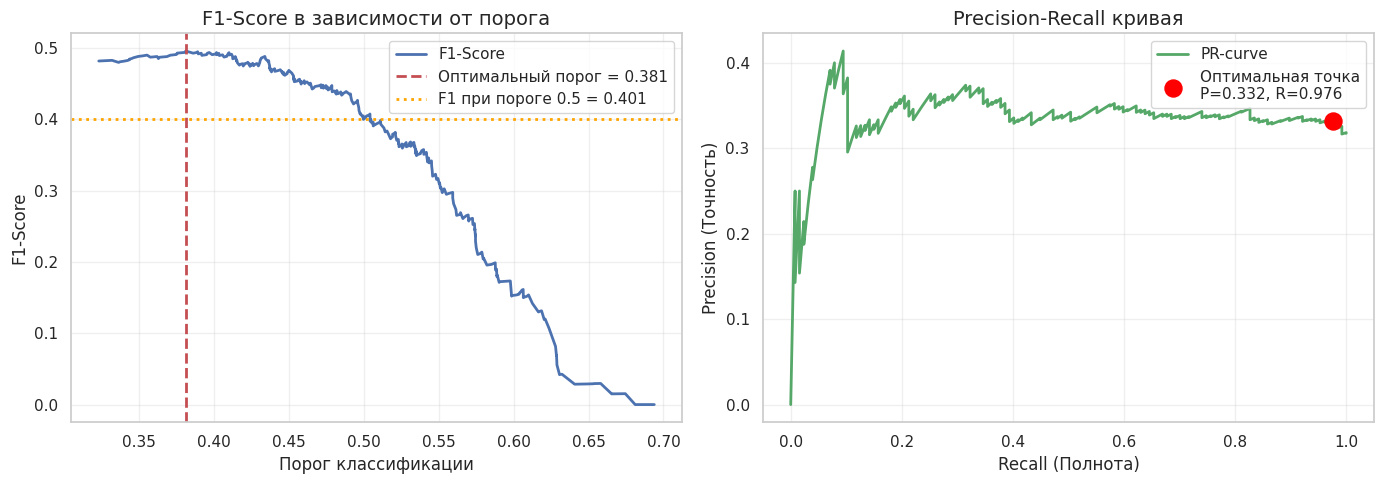

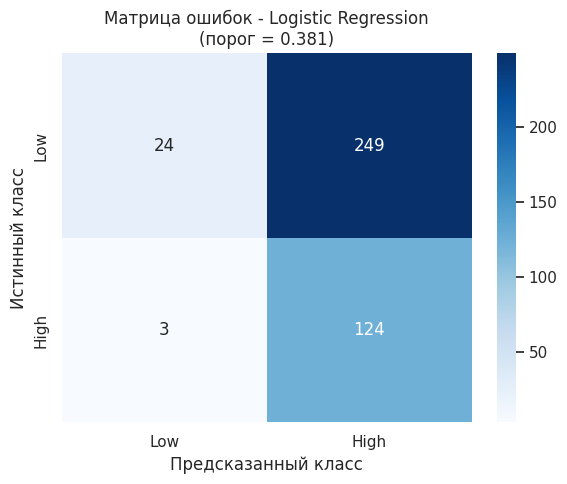

In [15]:
# Берем нашу лучшую модель логистик регрешн
best_pipeline = pipelines_correct[best_model_name]
y_proba_best = best_pipeline.predict_proba(X_test_c)[:, 1]

# Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test_c, y_proba_best)

# Вычисляем F1 для каждого порога
# У precision_recall_curve порог на 1 элемент меньше
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

# Находим оптимальный порог
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1_optimized = f1_scores[best_idx]

# F1 при пороге 0.5
f1_05 = results_df_correct[results_df_correct["model"] == best_model_name]["F1-Score"].values[0]

print(f"лучшая модель: {best_model_name}")
print(f"Порог 0.5:")
print(f"F1-Score: {f1_05:.4f}")
print(f"Оптимальный порог: {best_threshold:.4f}")
print(f"F1-Score при оптимальном пороге: {best_f1_optimized:.4f}")
print(f"Улучшение: +{best_f1_optimized - f1_05:.4f} (+{(best_f1_optimized/f1_05 - 1)*100:.1f}%)")

# Пересчет метрик при оптимальном пороге
y_pred_optimal = (y_proba_best >= best_threshold).astype(int)

print(f"Метрики при оптимальнром пороге ({best_threshold:.3f}):")
print(classification_report(y_test_c, y_pred_optimal, target_names=['Low', 'High']))

#Графики с вихуальизацией
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, f1_scores, 'b-', linewidth=2, label='F1-Score')
axes[0].axvline(x=best_threshold, color='r', linestyle='--', linewidth=2,
                label=f'Оптимальный порог = {best_threshold:.3f}')
axes[0].axhline(y=f1_05, color='orange', linestyle=':', linewidth=2,
                label=f'F1 при пороге 0.5 = {f1_05:.3f}')
axes[0].set_xlabel('Порог классификации', fontsize=12)
axes[0].set_ylabel('F1-Score', fontsize=12)
axes[0].set_title('F1-Score в зависимости от порога', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recalls[:-1], precisions[:-1], 'g-', linewidth=2, label='PR-curve')
axes[1].scatter(recalls[best_idx], precisions[best_idx], color='red', s=150, zorder=5,
                label=f'Оптимальная точка\nP={precisions[best_idx]:.3f}, R={recalls[best_idx]:.3f}')
axes[1].set_xlabel('Recall (Полнота)', fontsize=12)
axes[1].set_ylabel('Precision (Точность)', fontsize=12)
axes[1].set_title('Precision-Recall кривая', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Матрица ошибок при оптимальном пороге
cm = confusion_matrix(y_test_c, y_pred_optimal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок - {best_model_name}\n(порог = {best_threshold:.3f})')
plt.tight_layout()
plt.show()

УРА- корректный результат. Что имеем:
- 1\ Recall High = 0.98 --> модель находит 98% всех реально успешных автомобилей
- 2\ Precision High = 0.33 --> но при этом 67% предсказаний High оказываются ошибочными


---


Такой дисбаланс из-за настройки модели на поиск high - жертвуем точностью, тк лучше ошибиться и закупить лишний автомобиль, чем упустить прибыльный

- 4\ F1 вырос на 23.6%-оптимизация порога сработала отлично
- 5\ Из каждых 3 автомобилей, которые модель назвала High, 1 действительно будет успешно продаваться, а 2 окажутся неуспешными
- 6\ Из каждых 100 реально успешных автомобилей, 98 модель найдет и порекомендует к закупке, а 2 будут упущены (потерянная прибыль)


---

- При прроге 0.5 мы пропускаем половину прибыли
- При пороге 0.38 мы находим почти все, но с ошибками
- Какой выбрать зависит от приоритетов: если упускать прибыль критично, то 0.38, если ложные закупки очень дороги, то 0.5

**Оценка качества модели и выбранных метрик:**


---

Precision = доля правильно предсказанных High среди всех автомобилей, отмеченных моделью как High.Высокий Precision = мало ложных срабатываний.


---

Recall = доля реальных High, которые модель смогла найти. Высокий Recall = модель находит большинство успешных автомобилей.   


---

F1-Score = гармоническое среднее Precision и Recall. Лучшая метрика при дисбалансе классов.


---

**Увеличивает вероятность high (влияют на успешные продажи):**


---

- 1\ Модели М3, 7 series, 5 series
- 2\ Дизельные автомобили (традиционные двигатели)
- 3\ Рынок Европы
- 4\ Цена от 60k$$  до   80k$
- 5\ Легендарный синий цвет


---

**Рекомендации для дилерского центра:**


---

- Увеличить долю автомобилей с предсказанным классом High
- Сократить закупки автомобилей с высоким риском Low
- Использовать модель для скоринга перед принятием решения о закупке
- Для автомобилей с вероятностью High > 0.7 удерживать высокую маржу
- Для автомобилей с вероятностью Low > 0.7 предлагать скидки
- Продвигать автомобили моделей  М3, 7 series, 5 series
- Для электромобилей i3/i8 — специальные акции или trade-in программы
- Поддерживать оптимальный запас автомобилей с высоким спросом
- Избегать затоваривания автомобилями с предсказанным Low
- Внедрить систему автоматического пересмотра порога закупок

---


**Ограничения модели и пути решения:**


---



- (-) Данные могут быть синтетическими (низкие корреляции)
- (-) Отсутствуют временные метки (нельзя учесть сезонность)
- (-) Нет экономических показателей регионов
- (-) Отсутствуют данные о конкурентах и рыночной ситуации
- (+) Добавить признаки: сезонность, курс валют, инфляцию
- (+) Собирать больше реальных данных (не синтетических)
- (+) Внедрить кросс-валидацию для более стабильной оценки
- (+) Использовать ансамблевые методы (Stacking, Blending)
- (+) Регулярно дообучать модель на новых данных


---

